Proyek ini bertujuan untuk membangun sistem deteksi rambu lalu lintas sebagai komponen dasar sistem Autopilot Mobil. EDA ini difokuskan untuk mengidentifikasi tantangan teknis seperti variasi pencahayaan, deteksi objek berukuran kecil (small objects), dan bias posisi yang dapat memengaruhi keselamatan berkendara.

In [1]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm

/tmp/ipykernel_55/1044806466.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette='magma')


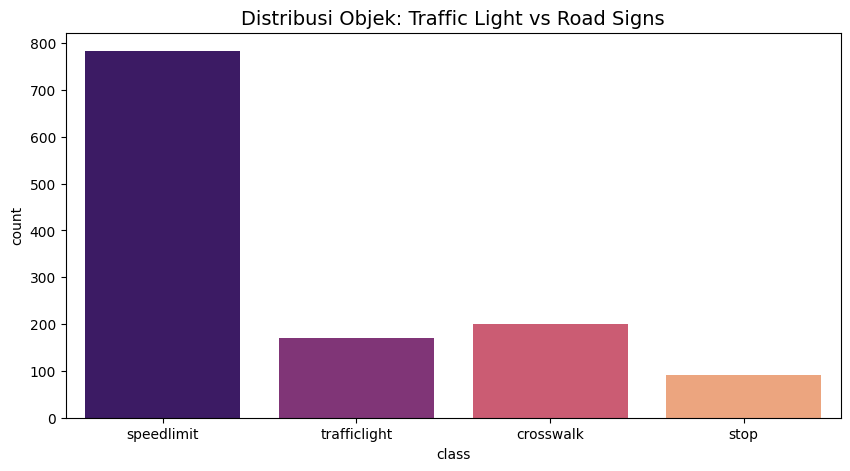

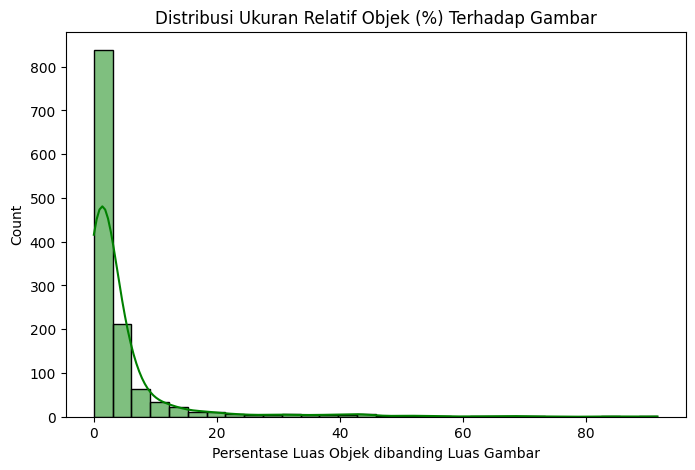

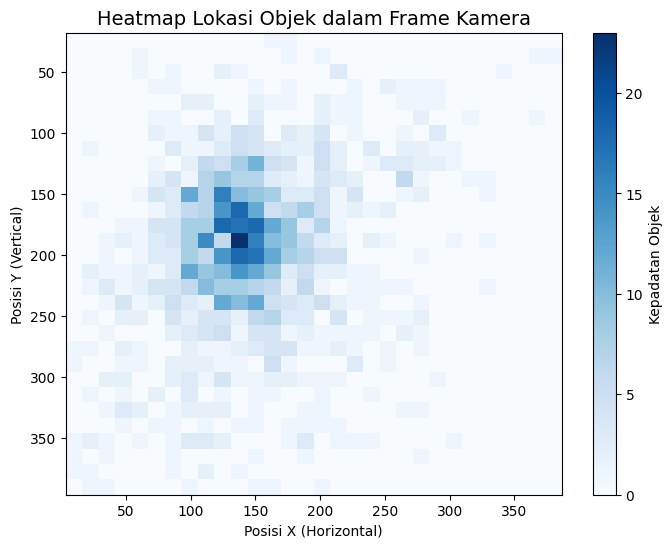

In [2]:
# 1. PARSING XML KE DATAFRAME
def parse_xml(ann_path):
    list_data = []
    for filename in os.listdir(ann_path):
        if not filename.endswith('.xml'): continue
        
        tree = ET.parse(os.path.join(ann_path, filename))
        root = tree.getroot()
        
        # Ambil ukuran gambar
        width = int(root.find('size').find('width').text)
        height = int(root.find('size').find('height').text)
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            bbox = obj.find('bndbox')
            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)
            
            # Hitung lebar dan tinggi bounding box (rambu)
            obj_width = xmax - xmin
            obj_height = ymax - ymin
            
            list_data.append([filename, width, height, name, xmin, ymin, xmax, ymax, obj_width, obj_height])
            
    return pd.DataFrame(list_data, columns=['file', 'img_w', 'img_h', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'obj_w', 'obj_h'])

# Sesuaikan path ini dengan struktur folder di Kaggle kamu
ANN_PATH = '/kaggle/input/datasets/andrewmvd/road-sign-detection/annotations' # Contoh path
df = parse_xml(ANN_PATH)

# 2. VISUALISASI DISTRIBUSI KELAS (Target Autopilot)
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='class', palette='magma')
plt.title('Distribusi Objek: Traffic Light vs Road Signs', fontsize=14)
plt.show()

# 3. ANALISIS UKURAN OBJEK (PENTING UNTUK DETEKSI JARAK JAUH)
# Menghitung seberapa besar objek dibanding ukuran gambar asli
df['rel_size'] = (df['obj_w'] * df['obj_h']) / (df['img_w'] * df['img_h']) * 100

plt.figure(figsize=(8, 5))
sns.histplot(df['rel_size'], bins=30, kde=True, color='green')
plt.title('Distribusi Ukuran Relatif Objek (%) Terhadap Gambar', fontsize=12)
plt.xlabel('Persentase Luas Objek dibanding Luas Gambar')
plt.show()

# 4. HEATMAP POSISI OBJEK (DI MANA RAMBU BIASANYA MUNCUL?)
plt.figure(figsize=(8, 6))
plt.hist2d(df['xmin'] + df['obj_w']/2, df['ymin'] + df['obj_h']/2, bins=30, cmap='Blues')
plt.colorbar(label='Kepadatan Objek')
plt.title('Heatmap Lokasi Objek dalam Frame Kamera', fontsize=14)
plt.xlabel('Posisi X (Horizontal)')
plt.ylabel('Posisi Y (Vertical)')
plt.gca().invert_yaxis() # Biar sesuai koordinat gambar
plt.show()

Berdasarkan grafik di atas, terlihat adanya ketidakseimbangan jumlah data antar kelas

Total XML: 877
Gambar hilang: 0


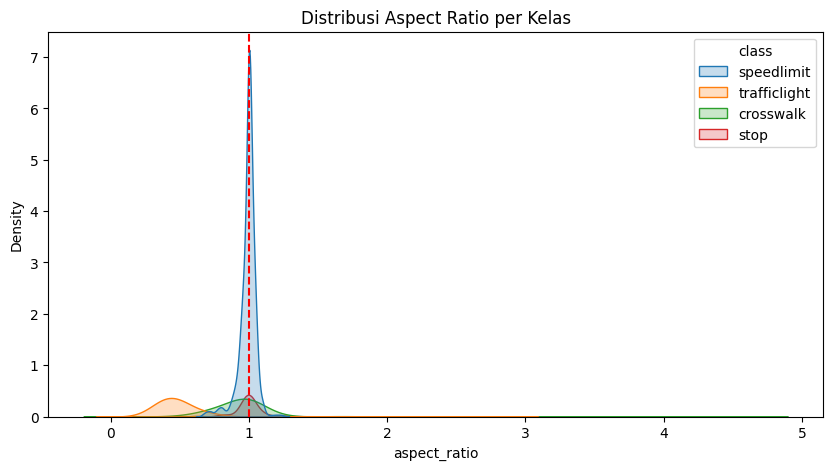

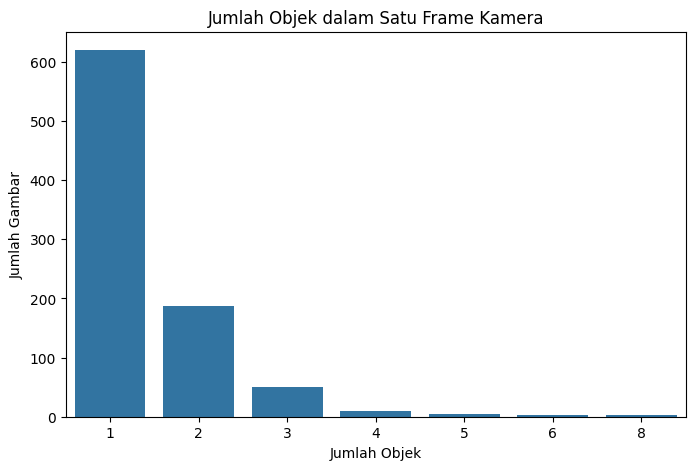

In [3]:
# Cek apakah setiap XML punya gambar yang sesuai
img_path = '/kaggle/input/datasets/andrewmvd/road-sign-detection/images'
missing_images = []

for xml_file in df['file'].unique():
    img_filename = xml_file.replace('.xml', '.png') # Sesuaikan ekstensi
    if not os.path.exists(os.path.join(img_path, img_filename)):
        missing_images.append(img_filename)

print(f"Total XML: {len(df['file'].unique())}")
print(f"Gambar hilang: {len(missing_images)}")

# Menghitung Aspect Ratio (Lebar / Tinggi)
df['aspect_ratio'] = df['obj_w'] / df['obj_h']

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='aspect_ratio', hue='class', fill=True)
plt.title('Distribusi Aspect Ratio per Kelas')
plt.axvline(1, color='red', linestyle='--') # Garis bantu untuk kotak sempurna (1:1)
plt.show()

# Menghitung jumlah objek per file gambar
objects_per_img = df.groupby('file')['class'].count()

plt.figure(figsize=(8, 5))
sns.countplot(x=objects_per_img)
plt.title('Jumlah Objek dalam Satu Frame Kamera')
plt.xlabel('Jumlah Objek')
plt.ylabel('Jumlah Gambar')
plt.show()



Analisis distribusi aspect ratio menunjukkan variasi bentuk objek yang signifikan antara trafficlight (vertikal) dan roadsign (cenderung persegi).

Rekomendasi: Pengaturan anchor boxes pada model deteksi (seperti YOLO) harus dikonfigurasi secara kustom agar sesuai dengan rasio unik ini, guna meningkatkan skor IoU (Intersection over Union) saat pengujian.

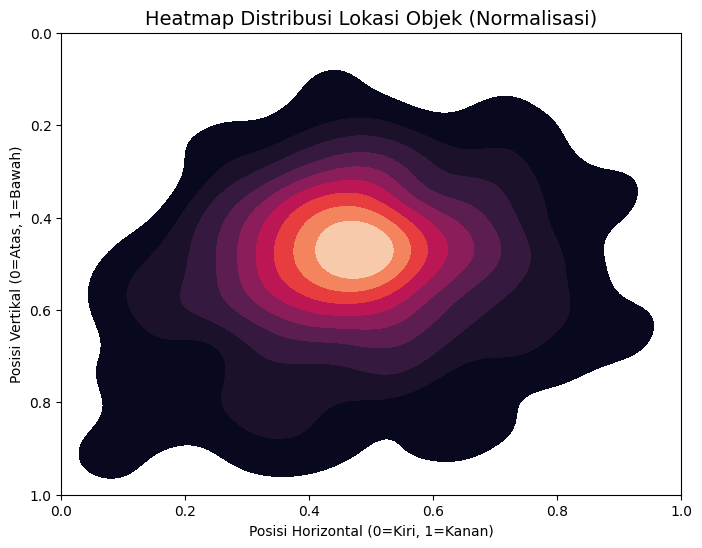

/tmp/ipykernel_55/775121164.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=sample_df, x='class', y='brightness', palette='coolwarm')


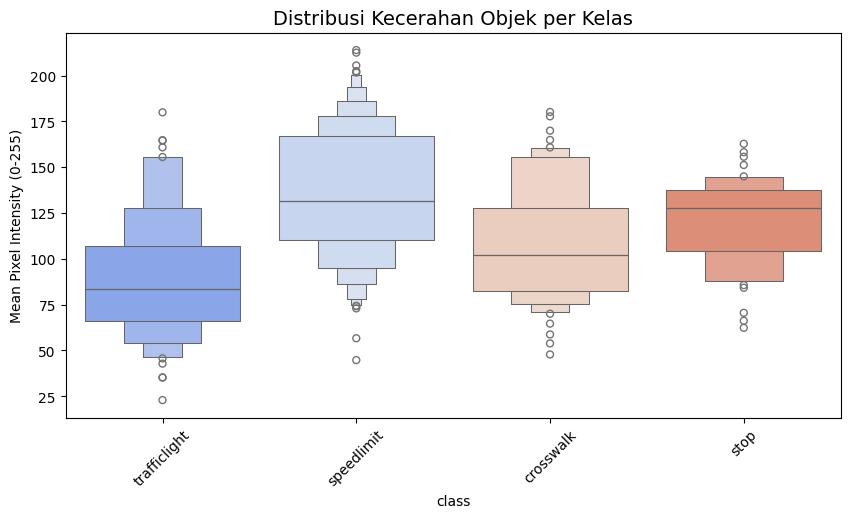

Rata-rata area gambar yang berisi objek: 4.46%
Objek terkecil: 0.0233%


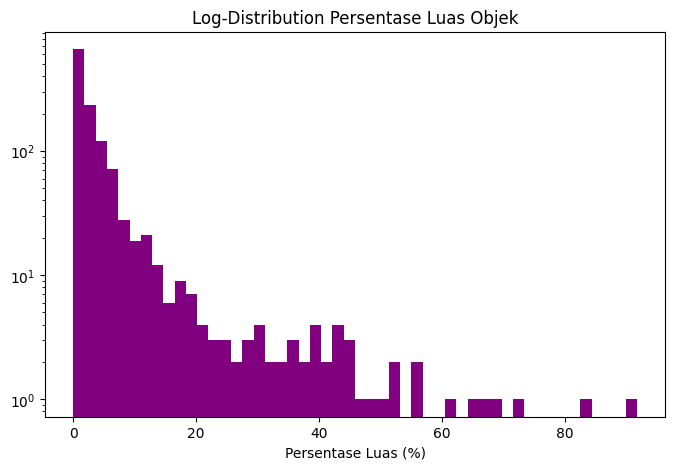

In [4]:
import numpy as np
# Menghitung titik tengah (x_center, y_center) yang dinormalisasi (0 sampai 1)
df['x_center_norm'] = (df['xmin'] + (df['obj_w'] / 2)) / df['img_w']
df['y_center_norm'] = (df['ymin'] + (df['obj_h'] / 2)) / df['img_h']

plt.figure(figsize=(8, 6))
sns.kdeplot(x=df['x_center_norm'], y=df['y_center_norm'], fill=True, cmap='rocket', thresh=0.05)
plt.title('Heatmap Distribusi Lokasi Objek (Normalisasi)', fontsize=14)
plt.xlabel('Posisi Horizontal (0=Kiri, 1=Kanan)')
plt.ylabel('Posisi Vertikal (0=Atas, 1=Bawah)')
plt.xlim(0, 1)
plt.ylim(1, 0) # Invert agar (0,0) di kiri atas
plt.show()

def get_brightness(img_path, xmin, ymin, xmax, ymax):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    crop = img[ymin:ymax, xmin:xmax]
    return np.mean(crop)

# Ambil sampel brightness untuk setiap objek
# (Gunakan sampel saja jika data terlalu besar)
sample_df = df.sample(min(500, len(df)))
sample_df['brightness'] = sample_df.apply(lambda row: get_brightness(
    os.path.join(img_path, row['file'].replace('.xml', '.png')), 
    row['xmin'], row['ymin'], row['xmax'], row['ymax']), axis=1)

plt.figure(figsize=(10, 5))
sns.boxenplot(data=sample_df, x='class', y='brightness', palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Distribusi Kecerahan Objek per Kelas', fontsize=14)
plt.ylabel('Mean Pixel Intensity (0-255)')
plt.show()

# Persentase area yang tertutup kotak deteksi dibanding total gambar
df['area_coverage'] = (df['obj_w'] * df['obj_h']) / (df['img_w'] * df['img_h']) * 100

print(f"Rata-rata area gambar yang berisi objek: {df['area_coverage'].mean():.2f}%")
print(f"Objek terkecil: {df['area_coverage'].min():.4f}%")

plt.figure(figsize=(8, 5))
plt.hist(df['area_coverage'], bins=50, color='purple', log=True) # Log scale karena biasanya banyak yang kecil
plt.title('Log-Distribution Persentase Luas Objek', fontsize=12)
plt.xlabel('Persentase Luas (%)')
plt.show()


Melalui analisis intensitas piksel, ditemukan beberapa sampel dengan kontras rendah yang mensimulasikan kondisi mendung atau backlight.

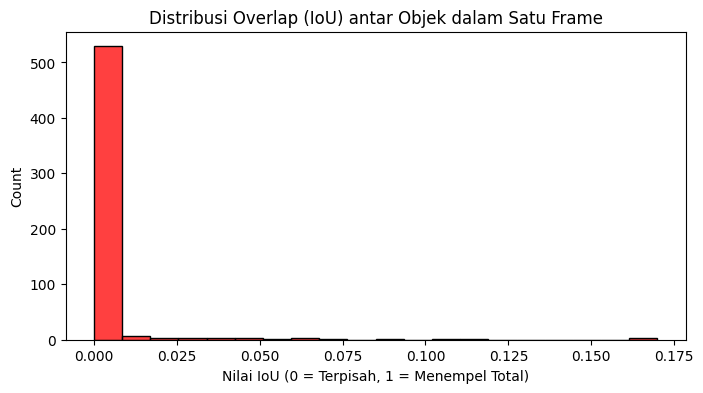

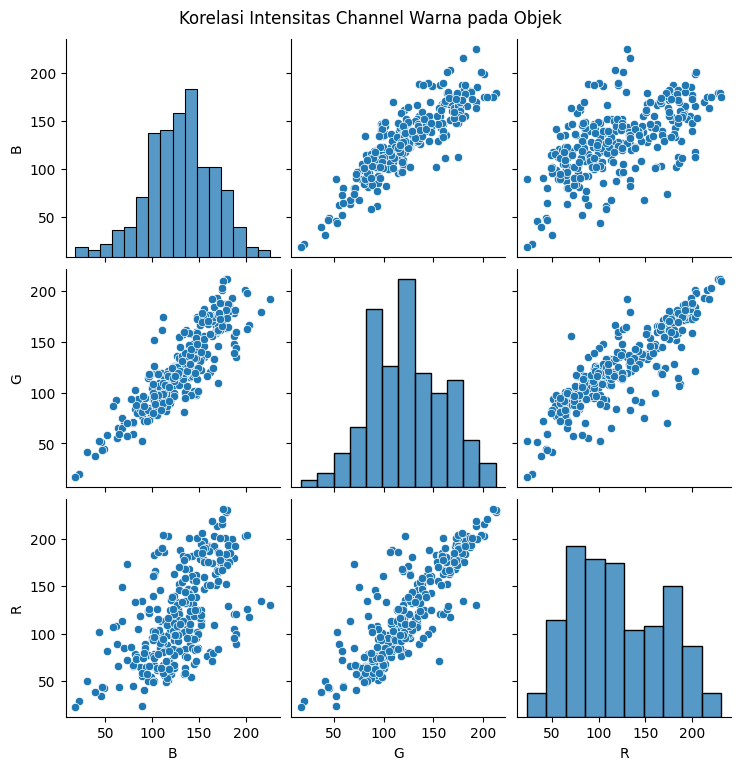

Persentase objek yang terpotong di pinggir frame: 4.98%


In [5]:
def calculate_iou(boxA, boxB):
    # Hitung koordinat perpotongan
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
    return interArea / float(boxAArea + boxBArea - interArea)

# Cek gambar yang punya lebih dari 1 objek
multi_obj_files = df.groupby('file').filter(lambda x: len(x) > 1)
ious = []

for file in multi_obj_files['file'].unique():
    objs = df[df['file'] == file][['xmin', 'ymin', 'xmax', 'ymax']].values
    for i in range(len(objs)):
        for j in range(i + 1, len(objs)):
            ious.append(calculate_iou(objs[i], objs[j]))

plt.figure(figsize=(8, 4))
sns.histplot(ious, bins=20, color='red')
plt.title('Distribusi Overlap (IoU) antar Objek dalam Satu Frame')
plt.xlabel('Nilai IoU (0 = Terpisah, 1 = Menempel Total)')
plt.show()

def get_dominant_color(img_path, box):
    img = cv2.imread(img_path)
    crop = img[box[1]:box[3], box[0]:box[2]]
    # Hitung rata-rata warna R, G, B
    avg_color = np.mean(crop, axis=(0, 1))
    return avg_color

# Ambil sampel rata-rata warna
sample_colors = df.sample(min(300, len(df)))
colors_list = []

for _, row in sample_colors.iterrows():
    path = os.path.join(img_path, row['file'].replace('.xml', '.png'))
    colors_list.append(get_dominant_color(path, [row['xmin'], row['ymin'], row['xmax'], row['ymax']]))

colors_df = pd.DataFrame(colors_list, columns=['B', 'G', 'R'])
sns.pairplot(colors_df)
plt.suptitle('Korelasi Intensitas Channel Warna pada Objek', y=1.02)
plt.show()

df['is_cut'] = ((df['xmin'] <= 5) | (df['ymin'] <= 5) | 
                (df['xmax'] >= df['img_w'] - 5) | 
                (df['ymax'] >= df['img_h'] - 5))

cut_count = df['is_cut'].sum()
print(f"Persentase objek yang terpotong di pinggir frame: {(cut_count/len(df))*100:.2f}%")

In [6]:
import os
import cv2
import xml.etree.ElementTree as ET
import numpy as np
from tqdm import tqdm
import shutil
import yaml
from sklearn.model_selection import train_test_split

# 1. KONFIGURASI
IMG_INPUT = '/kaggle/input/datasets/andrewmvd/road-sign-detection/images'
XML_INPUT = '/kaggle/input/datasets/andrewmvd/road-sign-detection/annotations'
BASE_OUTPUT = '/kaggle/working/road_sign_data' # Folder baru yang rapi
CLASSES = ["trafficlight", "speedlimit", "crosswalk", "stop"]

# Buat folder Train, Val, Test
for p in ['train/images', 'train/labels', 'val/images', 'val/labels', 'test/images', 'test/labels']:
    os.makedirs(os.path.join(BASE_OUTPUT, p), exist_ok=True)

def convert_to_yolo(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

# 2. SPLITTING DATA (80% Train, 10% Val, 10% Test)
all_xmls = [f.replace('.xml', '') for f in os.listdir(XML_INPUT) if f.endswith('.xml')]
train_files, test_files = train_test_split(all_xmls, test_size=0.2, random_state=42)
val_files, test_files = train_test_split(test_files, test_size=0.5, random_state=42)

# 3. FUNGSI PROSES
def process_dataset(file_list, set_name):
    print(f"Memproses {set_name} set...")
    for file_id in tqdm(file_list):
        xml_path = os.path.join(XML_INPUT, file_id + '.xml')
        
        # Parsing XML
        tree = ET.parse(xml_path)
        root = tree.getroot()
        img_name = root.find('filename').text
        img_path = os.path.join(IMG_INPUT, img_name)
        
        if not os.path.exists(img_path): continue

        w_orig = int(root.find('size').find('width').text)
        h_orig = int(root.find('size').find('height').text)

        # Preprocessing Gambar (CLAHE + Resize)
        img = cv2.imread(img_path)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        l = clahe.apply(l)
        img = cv2.merge((l,a,b))
        img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)
        img_resized = cv2.resize(img, (640, 640))
        
        cv2.imwrite(os.path.join(BASE_OUTPUT, set_name, 'images', img_name), img_resized)

        # Konversi Label
        with open(os.path.join(BASE_OUTPUT, set_name, 'labels', file_id + '.txt'), 'w') as f:
            for obj in root.findall('object'):
                cls = obj.find('name').text
                if cls not in CLASSES: continue
                cls_id = CLASSES.index(cls)
                xmlbox = obj.find('bndbox')
                b = (float(xmlbox.find('xmin').text), float(xmlbox.find('xmax').text), 
                     float(xmlbox.find('ymin').text), float(xmlbox.find('ymax').text))
                bb = convert_to_yolo((w_orig, h_orig), b)
                f.write(f"{cls_id} {' '.join([f'{a:.6f}' for a in bb])}\n")

# Eksekusi
process_dataset(train_files, 'train')
process_dataset(val_files, 'val')
process_dataset(test_files, 'test')

# 4. BUAT FILE YAML (Krusial untuk YOLO)
data_yaml = {
    'train': os.path.join(BASE_OUTPUT, 'train/images'),
    'val': os.path.join(BASE_OUTPUT, 'val/images'),
    'test': os.path.join(BASE_OUTPUT, 'test/images'),
    'nc': len(CLASSES),
    'names': CLASSES
}
with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("\nDataset Siap! File 'data.yaml' sudah dibuat.")

Memproses train set...


100%|██████████| 701/701 [00:32<00:00, 21.90it/s]


Memproses val set...


100%|██████████| 88/88 [00:04<00:00, 21.65it/s]


Memproses test set...


100%|██████████| 88/88 [00:03<00:00, 22.61it/s]


Dataset Siap! File 'data.yaml' sudah dibuat.


In [7]:
import os

for root, dirs, files in os.walk('/kaggle/working'):
    print(root)

/kaggle/working
/kaggle/working/road_sign_data
/kaggle/working/road_sign_data/train
/kaggle/working/road_sign_data/train/images
/kaggle/working/road_sign_data/train/labels
/kaggle/working/road_sign_data/test
/kaggle/working/road_sign_data/test/images
/kaggle/working/road_sign_data/test/labels
/kaggle/working/road_sign_data/val
/kaggle/working/road_sign_data/val/images
/kaggle/working/road_sign_data/val/labels
/kaggle/working/.virtual_documents


In [8]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/andrewmvd
/kaggle/input/datasets/andrewmvd/road-sign-detection
/kaggle/input/datasets/andrewmvd/road-sign-detection/annotations
/kaggle/input/datasets/andrewmvd/road-sign-detection/images


In [9]:
import os
import xml.etree.ElementTree as ET
import shutil
import random

In [10]:
BASE_PATH = "/kaggle/input/datasets/andrewmvd/road-sign-detection"
IMG_PATH = os.path.join(BASE_PATH, "images")
ANN_PATH = os.path.join(BASE_PATH, "annotations")

OUTPUT_PATH = "/kaggle/working/dataset"

In [11]:
for folder in [
    "images/train", "images/val",
    "labels/train", "labels/val"
]:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

# Ambil hanya speed limit
classes = {
    "speed limit 20": 0,
    "speed limit 30": 1,
    "speed limit 50": 2,
    "speed limit 60": 3,
    "speed limit 70": 4,
    "speed limit 80": 5,
    "speed limit 100": 6,
    "speed limit 120": 7
}

def convert_to_yolo(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x_center = (box[0] + box[1]) / 2.0
    y_center = (box[2] + box[3]) / 2.0

    w = box[1] - box[0]
    h = box[3] - box[2]

    x_center *= dw
    w *= dw
    y_center *= dh
    h *= dh

    return (x_center, y_center, w, h)

all_files = os.listdir(ANN_PATH)
random.shuffle(all_files)

split = int(0.8 * len(all_files))
train_files = all_files[:split]
val_files = all_files[split:]

def process(files, split_type):
    for file in files:
        xml_file = os.path.join(ANN_PATH, file)
        tree = ET.parse(xml_file)
        root = tree.getroot()

        img_name = root.find("filename").text
        img_path = os.path.join(IMG_PATH, img_name)

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        label_path = os.path.join(
            OUTPUT_PATH, f"labels/{split_type}/{img_name.replace('.jpg','.txt')}"
        )

        with open(label_path, "w") as f:
            for obj in root.iter("object"):
                cls = obj.find("name").text.lower()

                if cls not in classes:
                    continue  # skip non speed limit

                cls_id = classes[cls]

                xmlbox = obj.find("bndbox")
                b = (
                    float(xmlbox.find("xmin").text),
                    float(xmlbox.find("xmax").text),
                    float(xmlbox.find("ymin").text),
                    float(xmlbox.find("ymax").text)
                )

                bb = convert_to_yolo((w, h), b)
                f.write(f"{cls_id} {' '.join(map(str, bb))}\n")

        shutil.copy(img_path, os.path.join(
            OUTPUT_PATH, f"images/{split_type}/{img_name}"
        ))

process(train_files, "train")
process(val_files, "val")

print("DONE CONVERTING DATASET")

DONE CONVERTING DATASET


In [12]:
import shutil

shutil.rmtree('/kaggle/working/dataset', ignore_errors=True)
print("✅ Reset done")

✅ Reset done


In [13]:
import os
import xml.etree.ElementTree as ET
import shutil
import random

BASE_PATH = "/kaggle/input/datasets/andrewmvd/road-sign-detection"
IMG_PATH = os.path.join(BASE_PATH, "images")
ANN_PATH = os.path.join(BASE_PATH, "annotations")

OUTPUT_PATH = "/kaggle/working/dataset"

# buat folder
for folder in [
    "images/train", "images/val",
    "labels/train", "labels/val"
]:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

# class mapping (speed limit only)
classes = {
    "speed limit 20": 0,
    "speed limit 30": 1,
    "speed limit 50": 2,
    "speed limit 60": 3,
    "speed limit 70": 4,
    "speed limit 80": 5,
    "speed limit 100": 6,
    "speed limit 120": 7
}

def convert_to_yolo(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]

    return x*dw, y*dh, w*dw, h*dh

# ambil semua xml
all_files = [f for f in os.listdir(ANN_PATH) if f.endswith(".xml")]
random.shuffle(all_files)

split = int(0.8 * len(all_files))
train_files = all_files[:split]
val_files = all_files[split:]


def process(files, split_type):
    for file in files:
        xml_file = os.path.join(ANN_PATH, file)
        tree = ET.parse(xml_file)
        root = tree.getroot()

        img_name = root.find("filename").text
        img_path = os.path.join(IMG_PATH, img_name)

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        # 👉 path label (PASTI .txt)
        label_file = img_name.replace(".png", ".txt").replace(".jpg", ".txt")
        label_path = os.path.join(OUTPUT_PATH, f"labels/{split_type}/{label_file}")

        valid = False  # cek apakah ada object yg kepake

        with open(label_path, "w") as f:
            for obj in root.iter("object"):
                cls = obj.find("name").text.lower()

                if cls not in classes:
                    continue

                cls_id = classes[cls]

                xmlbox = obj.find("bndbox")
                xmin = float(xmlbox.find("xmin").text)
                xmax = float(xmlbox.find("xmax").text)
                ymin = float(xmlbox.find("ymin").text)
                ymax = float(xmlbox.find("ymax").text)

                bb = convert_to_yolo((w, h), (xmin, xmax, ymin, ymax))
                f.write(f"{cls_id} {' '.join(map(str, bb))}\n")
                valid = True

        # 👉 kalau ada speed limit → copy image
        if valid:
            shutil.copy(img_path, os.path.join(
                OUTPUT_PATH, f"images/{split_type}/{img_name}"
            ))
        else:
            os.remove(label_path)  # hapus label kosong


process(train_files, "train")
process(val_files, "val")

print("DONE FIXED CONVERSION")

DONE FIXED CONVERSION


In [14]:
classes = {
    "speedlimit": 0
}

In [15]:
import shutil
shutil.rmtree('/kaggle/working/dataset', ignore_errors=True)
print("Reset done")

Reset done


In [16]:
import os
import xml.etree.ElementTree as ET
import shutil
import random

BASE_PATH = "/kaggle/input/datasets/andrewmvd/road-sign-detection"
IMG_PATH = os.path.join(BASE_PATH, "images")
ANN_PATH = os.path.join(BASE_PATH, "annotations")

OUTPUT_PATH = "/kaggle/working/dataset"

# buat folder
for folder in [
    "images/train", "images/val",
    "labels/train", "labels/val"
]:
    os.makedirs(os.path.join(OUTPUT_PATH, folder), exist_ok=True)

def convert_to_yolo(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]

    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]

    return x*dw, y*dh, w*dw, h*dh

# ambil semua xml
all_files = [f for f in os.listdir(ANN_PATH) if f.endswith(".xml")]
random.shuffle(all_files)

split = int(0.8 * len(all_files))
train_files = all_files[:split]
val_files = all_files[split:]

def process(files, split_type):
    for file in files:
        xml_file = os.path.join(ANN_PATH, file)
        tree = ET.parse(xml_file)
        root = tree.getroot()

        img_name = root.find("filename").text
        img_path = os.path.join(IMG_PATH, img_name)

        size = root.find("size")
        w = int(size.find("width").text)
        h = int(size.find("height").text)

        label_file = img_name.replace(".png", ".txt").replace(".jpg", ".txt")
        label_path = os.path.join(OUTPUT_PATH, f"labels/{split_type}/{label_file}")

        valid = False

        with open(label_path, "w") as f:
            for obj in root.iter("object"):
                cls = obj.find("name").text.lower().replace(" ", "")

                # 🔥 FIX: fleksibel detect speedlimit
                if "speedlimit" not in cls:
                    continue

                cls_id = 0

                xmlbox = obj.find("bndbox")
                xmin = float(xmlbox.find("xmin").text)
                xmax = float(xmlbox.find("xmax").text)
                ymin = float(xmlbox.find("ymin").text)
                ymax = float(xmlbox.find("ymax").text)

                bb = convert_to_yolo((w, h), (xmin, xmax, ymin, ymax))
                f.write(f"{cls_id} {' '.join(map(str, bb))}\n")
                valid = True

        if valid:
            shutil.copy(img_path, os.path.join(
                OUTPUT_PATH, f"images/{split_type}/{img_name}"
            ))
        else:
            os.remove(label_path)

process(train_files, "train")
process(val_files, "val")

print("DONE")

DONE


In [17]:
import os

print("LABELS:", os.listdir('/kaggle/working/dataset/labels/train')[:5])
print("IMAGES:", os.listdir('/kaggle/working/dataset/images/train')[:5])

LABELS: ['road668.txt', 'road482.txt', 'road432.txt', 'road843.txt', 'road773.txt']
IMAGES: ['road758.png', 'road727.png', 'road340.png', 'road593.png', 'road390.png']


In [18]:
import os

img_files = set([f.replace('.png','').replace('.jpg','') 
                 for f in os.listdir('/kaggle/working/dataset/images/train')])

label_files = set([f.replace('.txt','') 
                   for f in os.listdir('/kaggle/working/dataset/labels/train')])

print("Mismatch:", img_files - label_files)

Mismatch: set()


In [19]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.7 MB/s eta 0:00:00a 0:00:01


In [20]:
data_yaml = """
path: /kaggle/working/dataset

train: images/train
val: images/val

names:
  0: speedlimit
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

In [21]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="speedlimit_detector"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.27 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ke

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78648e4d1b50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [25]:
"runs/detect/speedlimit_detector/weights/best.pt"
from ultralytics import YOLO

model = YOLO("runs/detect/speedlimit_detector/weights/best.pt")
results = model.predict(
    source="/kaggle/working/dataset/images/val",
    conf=0.25,
    save=True
)


image 1/133 /kaggle/working/dataset/images/val/road104.png: 608x640 1 speedlimit, 40.8ms
image 2/133 /kaggle/working/dataset/images/val/road106.png: 640x448 1 speedlimit, 42.1ms
image 3/133 /kaggle/working/dataset/images/val/road117.png: 384x640 1 speedlimit, 41.3ms
image 4/133 /kaggle/working/dataset/images/val/road161.png: 640x480 1 speedlimit, 40.9ms
image 5/133 /kaggle/working/dataset/images/val/road163.png: 640x480 1 speedlimit, 5.9ms
image 6/133 /kaggle/working/dataset/images/val/road172.png: 640x480 1 speedlimit, 5.9ms
image 7/133 /kaggle/working/dataset/images/val/road174.png: 640x480 1 speedlimit, 5.9ms
image 8/133 /kaggle/working/dataset/images/val/road177.png: 640x480 1 speedlimit, 6.0ms
image 9/133 /kaggle/working/dataset/images/val/road188.png: 640x480 1 speedlimit, 5.9ms
image 10/133 /kaggle/working/dataset/images/val/road198.png: 640x480 1 speedlimit, 5.9ms
image 11/133 /kaggle/working/dataset/images/val/road206.png: 640x480 1 speedlimit, 5.9ms
image 12/133 /kaggle/work

FileNotFoundError: /kaggle/working/dataset/images/val/road394.png does not exist